
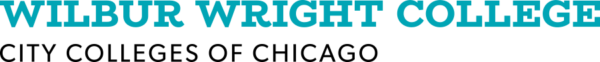
<h1><b><u>The Titanic Prediction Model</u></b><h1>
<h1><b>Initial Setup</b></h1>
<h2>Tasks:</h2>
<p>1. Importing the following libraries: warnings, numpy, pandas, matplotlib and seaborn.</p>
<p>2. Defining Style.</p>
<p>3. Uploading train and test dataset from github (80% - 20%)</p>
<p>4. Showing data</p>

In [28]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
plt.style.use('dark_background')
%matplotlib inline
warnings.filterwarnings('ignore')

train = pd.read_csv('/content/drive/MyDrive/train.csv')
test = pd.read_csv('/content/drive/MyDrive/wrighttest.csv')
#test = pd.read_csv('/content/drive/MyDrive/test.csv')

#train = pd.read_csv('https://raw.githubusercontent.com/galatta/datasets/refs/heads/main/train.csv')
#test = pd.read_csv('https://raw.githubusercontent.com/galatta/datasets/refs/heads/main/test.csv')

#train = pd.read_csv('https://datasets-bucket-itclub.s3.us-east-1.amazonaws.com/train.csv')
#test = pd.read_csv('https://datasets-bucket-itclub.s3.us-east-1.amazonaws.com/test.csv')

# To know number of columns and rows
train.shape
# (891, 12)

print(train.to_string())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     PassengerId  Survived  Pclass                                                                                Name     Sex    Age  SibSp  Parch              Ticket      Fare            Cabin Embarked
0              1         0       3                                                             Braund, Mr. Owen Harris    male  22.00      1      0           A/5 21171    7.2500              NaN        S
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.00      1      0            PC 17599   71.2833              C85        C
2              3         1       3                                                              Heikkinen, Miss. Laina  female  26.00      0      0    STON/O2. 3101282    7.9250              NaN        S
3              4         1       1                     

## **Show metadata from the train dataset**

In [ ]:
https://notebooklm.google.com/notebook/cc069b65-e80c-46a6-b055-1f4e2fe76b27?artifactId=191c0cb5-1d4c-440a-85be-ce273719e14atrain.info
https://notebooklm.google.com/notebook/cc069b65-e80c-46a6-b055-1f4e2fe76b27?artifactId=191c0cb5-1d4c-440a-85be-ce273719e14anote
https://notebooklm.google.com/notebook/cc069b65-e80c-46a6-b055-1f4e2fe76b27?artifactId=191c0cb5-1d4c-440a-85be-ce273719e14atrain.info
https://notebooklm.google.com/notebook/cc069b65-e80c-46a6-b055-1f4e2fe76b27?artifactId=191c0cb5-1d4c-440a-85be-ce273719e14atrain.info
train.info

<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ...    ...   
886                              Montvila, Rev. Juozas    male  27.0      0   
887                       Graham, Miss. Margaret Edith  female  19.0      0   
888           Johnston, Miss. Catherine Helen "Carrie"  female   NaN      1   
889                              Behr, Mr. Karl Howell    male  26.0      0   
890                                Dooley, Mr. Patrick    male  32.0      0   

     Parch            Ticket     Fare Cabin Embarked  
0        0         A/5 21171   7.2500   NaN        S  
1        0          PC 17599  71.2833   C85        C  
2        0  STON/O2. 3101282   7.9250   NaN        S  
3        0            113803  53.1000  C123        S  
4        0            373450   8.0500   NaN        S  
..     ...               ...      ...   ...      ...  
886      0            211536  13.0000   NaN        S  
887      0            112053  30.0000   B42        S  
888      2        W./C. 6607  23.4500   NaN        S  
889      0            111369  30.0000  C148        C  
890      0            370376   7.7500   NaN        Q  

[891 rows x 12 columns]>

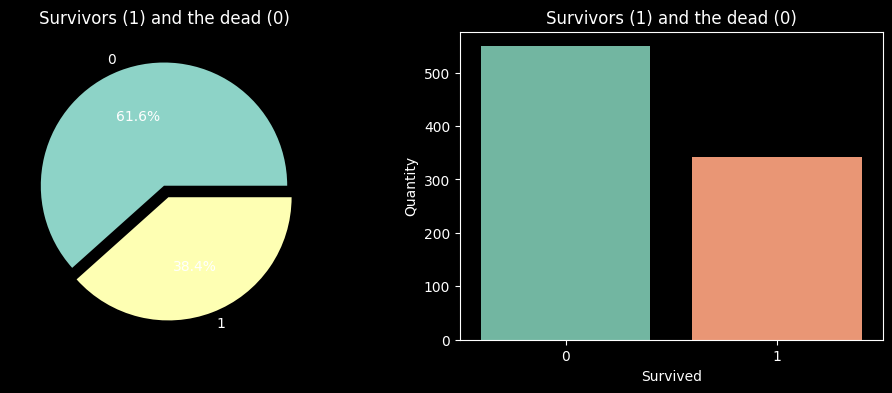

In [29]:
f, ax = plt.subplots(1, 2, figsize=(12, 4))
#f, ax = plt.subplots(figsize=(12, 4))
# Pie chart
train['Survived'].value_counts().plot.pie(
    explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=False)
ax[0].set_title('Survivors (1) and the dead (0)')
ax[0].set_ylabel('')

# Count plot
sns.countplot(x='Survived', data=train, ax=ax[1], palette="Set2")
ax[1].set_ylabel('Quantity')
ax[1].set_title('Survivors (1) and the dead (0)')
plt.show()


# Analyzing gender by survival: see chances of surviving by **gender**

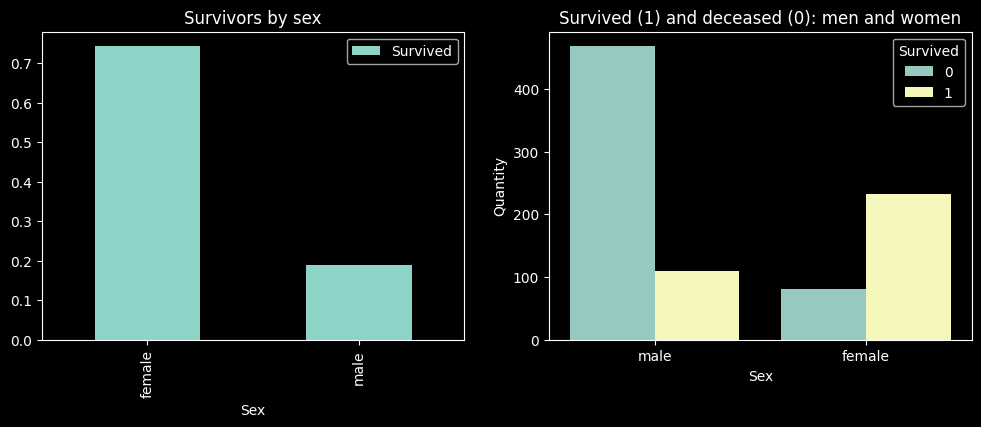

In [30]:
f, ax = plt.subplots(1, 2, figsize=(12, 4))

#count 1
train[['Sex', 'Survived']].groupby(['Sex']).mean().plot.bar(ax=ax[0])
ax[0].set_title('Survivors by sex')

#count 2
sns.countplot(x='Sex', hue='Survived', data=train, ax=ax[1])
ax[1].set_ylabel('Quantity')
ax[1].set_title('Survived (1) and deceased (0): men and women')
plt.show()

# This code is modified by Gustavo Alatta

<h1>Summarize NULL data per column</h1>

In [ ]:
train.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [33]:
train = train.drop(['Cabin'], axis=1)
test = test.drop(['Cabin'], axis=1)
train = train.drop(['Ticket'], axis=1)
test = test.drop(['Ticket'], axis=1)
print(train.to_string())

     PassengerId  Survived  Pclass                                                                                Name     Sex    Age  SibSp  Parch      Fare Embarked     AgeGroup
0              1         0       3                                                             Braund, Mr. Owen Harris    male  22.00      1      0    7.2500        S      Student
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.00      1      0   71.2833        C        Adult
2              3         1       3                                                              Heikkinen, Miss. Laina  female  26.00      0      0    7.9250        S  Young Adult
3              4         1       1                                        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.00      1      0   53.1000        S  Young Adult
4              5         0       3                                                            Allen,

In [34]:
# replacing the missing values in
# the Embarked feature with S
train = train.fillna({"Embarked": "S"})
print(train.to_string())

     PassengerId  Survived  Pclass                                                                                Name     Sex    Age  SibSp  Parch      Fare Embarked     AgeGroup
0              1         0       3                                                             Braund, Mr. Owen Harris    male  22.00      1      0    7.2500        S      Student
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.00      1      0   71.2833        C        Adult
2              3         1       3                                                              Heikkinen, Miss. Laina  female  26.00      0      0    7.9250        S  Young Adult
3              4         1       1                                        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.00      1      0   53.1000        S  Young Adult
4              5         0       3                                                            Allen,

In [35]:
# sort the ages into logical categories
train["Age"] = train["Age"].fillna(-0.5)
test["Age"] = test["Age"].fillna(-0.5)
bins = [-1, 0, 5, 12, 18, 24, 35, 60, np.inf]
labels = ['Unknown', 'Baby', 'Child', 'Teenager',
          'Student', 'Young Adult', 'Adult', 'Senior']
train['AgeGroup'] = pd.cut(train["Age"], bins, labels=labels)
test['AgeGroup'] = pd.cut(test["Age"], bins, labels=labels)
print(train.to_string())

     PassengerId  Survived  Pclass                                                                                Name     Sex    Age  SibSp  Parch      Fare Embarked     AgeGroup
0              1         0       3                                                             Braund, Mr. Owen Harris    male  22.00      1      0    7.2500        S      Student
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.00      1      0   71.2833        C        Adult
2              3         1       3                                                              Heikkinen, Miss. Laina  female  26.00      0      0    7.9250        S  Young Adult
3              4         1       1                                        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.00      1      0   53.1000        S  Young Adult
4              5         0       3                                                            Allen,

In [36]:
# create a combined group of both datasets
combine = [train, test]

# extract a title for each Name in the
# train and test datasets
for dataset in combine:
    dataset['Title'] = dataset.Name.str.extract(' ([A-Za-z]+)\.', expand=False)

#pd.crosstab(train['Title'], train['Sex'])

# replace various titles with more common names
for dataset in combine:
    dataset['Title'] = dataset['Title'].replace(['Lady', 'Capt', 'Col',
                                                 'Don', 'Dr', 'Major',
                                                 'Rev', 'Jonkheer', 'Dona'],
                                                'Rare')

    dataset['Title'] = dataset['Title'].replace(
        ['Countess', 'Lady', 'Sir'], 'Royal')
    dataset['Title'] = dataset['Title'].replace('Mlle', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Ms', 'Miss')
    dataset['Title'] = dataset['Title'].replace('Mme', 'Mrs')

#train[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

# map each of the title groups to a numerical value
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3,
                 "Master": 4, "Royal": 5, "Rare": 6}
for dataset in combine:
    dataset['Title'] = dataset['Title'].map(title_mapping)
    dataset['Title'] = dataset['Title'].fillna(0)



In [37]:
pd.crosstab(train['Title'], train['Sex'])

Sex,female,male
Title,,
1,0,517
2,185,0
3,126,0
4,0,40
5,1,1
6,2,19


In [38]:
train[['Title', 'Survived']].groupby(['Title'], as_index=False).mean()

,Title,Survived
0,1,0.156673
1,2,0.702703
2,3,0.793651
3,4,0.575000
4,5,1.000000
5,6,0.285714


In [39]:
mr_age = train[train["Title"] == 1]["AgeGroup"].mode()  # Young Adult
miss_age = train[train["Title"] == 2]["AgeGroup"].mode()  # Student
mrs_age = train[train["Title"] == 3]["AgeGroup"].mode()  # Adult
master_age = train[train["Title"] == 4]["AgeGroup"].mode()  # Baby
royal_age = train[train["Title"] == 5]["AgeGroup"].mode()  # Adult
rare_age = train[train["Title"] == 6]["AgeGroup"].mode()  # Adult

age_title_mapping = {1: "Young Adult", 2: "Student",
                     3: "Adult", 4: "Baby", 5: "Adult", 6: "Adult"}

for x in range(len(train["AgeGroup"])):
    if train["AgeGroup"][x] == "Unknown":
        train["AgeGroup"][x] = age_title_mapping[train["Title"][x]]

for x in range(len(test["AgeGroup"])):
    if test["AgeGroup"][x] == "Unknown":
        test["AgeGroup"][x] = age_title_mapping[test["Title"][x]]

In [40]:
print(train.to_string())

     PassengerId  Survived  Pclass                                                                                Name     Sex    Age  SibSp  Parch      Fare Embarked     AgeGroup  Title
0              1         0       3                                                             Braund, Mr. Owen Harris    male  22.00      1      0    7.2500        S      Student      1
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.00      1      0   71.2833        C        Adult      3
2              3         1       3                                                              Heikkinen, Miss. Laina  female  26.00      0      0    7.9250        S  Young Adult      2
3              4         1       1                                        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.00      1      0   53.1000        S  Young Adult      3
4              5         0       3                               

Normalize the age category assigning nymeric values.. then we don't need the age anymore... drop it

In [41]:
# map each Age value to a numerical value
age_mapping = {'Baby': 1, 'Child': 2, 'Teenager': 3,
               'Student': 4, 'Young Adult': 5, 'Adult': 6,
               'Senior': 7}
train['AgeGroup'] = train['AgeGroup'].map(age_mapping)
test['AgeGroup'] = test['AgeGroup'].map(age_mapping)

train.head()

# dropping the Age feature for now, might change
train = train.drop(['Age'], axis=1)
test = test.drop(['Age'], axis=1)

In [42]:
print(train.to_string())

     PassengerId  Survived  Pclass                                                                                Name     Sex  SibSp  Parch      Fare Embarked  AgeGroup  Title
0              1         0       3                                                             Braund, Mr. Owen Harris    male      1      0    7.2500        S       4.0      1
1              2         1       1                                 Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female      1      0   71.2833        C       6.0      3
2              3         1       3                                                              Heikkinen, Miss. Laina  female      0      0    7.9250        S       5.0      2
3              4         1       1                                        Futrelle, Mrs. Jacques Heath (Lily May Peel)  female      1      0   53.1000        S       5.0      3
4              5         0       3                                                            Allen, Mr. William He

Drop the name feature since there are no more useful information

In [43]:
train = train.drop(['Name'], axis=1)
test = test.drop(['Name'], axis=1)

Normalizing values for sex and embarks

In [44]:
sex_mapping = {"male": 0, "female": 1}
train['Sex'] = train['Sex'].map(sex_mapping)
test['Sex'] = test['Sex'].map(sex_mapping)

embarked_mapping = {"S": 1, "C": 2, "Q": 3}
train['Embarked'] = train['Embarked'].map(embarked_mapping)
test['Embarked'] = test['Embarked'].map(embarked_mapping)

In [45]:
print(train.to_string())

     PassengerId  Survived  Pclass  Sex  SibSp  Parch      Fare  Embarked  AgeGroup  Title
0              1         0       3    0      1      0    7.2500         1       4.0      1
1              2         1       1    1      1      0   71.2833         2       6.0      3
2              3         1       3    1      0      0    7.9250         1       5.0      2
3              4         1       1    1      1      0   53.1000         1       5.0      3
4              5         0       3    0      0      0    8.0500         1       5.0      1
5              6         0       3    0      0      0    8.4583         3       5.0      1
6              7         0       1    0      0      0   51.8625         1       6.0      1
7              8         0       3    0      3      1   21.0750         1       1.0      4
8              9         1       3    1      0      2   11.1333         1       5.0      3
9             10         1       2    1      1      0   30.0708         2       3.0      3

Fill Fare with mean fare and create fareband then drop fare

In [46]:
for x in range(len(test["Fare"])):
    if pd.isnull(test["Fare"][x]):
        pclass = test["Pclass"][x]  # Pclass = 3
        test["Fare"][x] = round(
            train[train["Pclass"] == pclass]["Fare"].mean(), 4)

# map Fare values into groups of
# numerical values
train['FareBand'] = pd.qcut(train['Fare'], 4,
                            labels=[1, 2, 3, 4])
test['FareBand'] = pd.qcut(test['Fare'], 4,
                           labels=[1, 2, 3, 4])

# drop Fare values
train = train.drop(['Fare'], axis=1)
test = test.drop(['Fare'], axis=1)

In [47]:
print(train.to_string())

     PassengerId  Survived  Pclass  Sex  SibSp  Parch  Embarked  AgeGroup  Title FareBand
0              1         0       3    0      1      0         1       4.0      1        1
1              2         1       1    1      1      0         2       6.0      3        4
2              3         1       3    1      0      0         1       5.0      2        2
3              4         1       1    1      1      0         1       5.0      3        4
4              5         0       3    0      0      0         1       5.0      1        2
5              6         0       3    0      0      0         3       5.0      1        2
6              7         0       1    0      0      0         1       6.0      1        4
7              8         0       3    0      3      1         1       1.0      4        3
8              9         1       3    1      0      2         1       5.0      3        2
9             10         1       2    1      1      0         2       3.0      3        3
10        

<h1>Training Time</h1>
<p>Creating the predictor and the target</p>
<p>Spliting the data for checking accuracy</p>

In [48]:
from sklearn.model_selection import train_test_split

# Drop the Survived and PassengerId
# column from the trainset
predictors = train.drop(['Survived', 'PassengerId'], axis=1)
target = train["Survived"]
x_train, x_val, y_train, y_val = train_test_split(
    predictors, target, test_size=0.2, random_state=0)

Training the model using the Random Forest

In [52]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

randomforest = RandomForestClassifier()

# Fit the training data along with its output
randomforest.fit(x_train, y_train)
y_pred = randomforest.predict(x_val)

# Find the accuracy score of the model
acc_randomforest = round(accuracy_score(y_pred, y_val) * 100, 2)
print(acc_randomforest)

84.92


Testing the Model with Test Dataset

In [53]:
ids = test['PassengerId']
predictions = randomforest.predict(test.drop('PassengerId', axis=1))

# set the output as a dataframe and convert
# to csv file named resultfile.csv
output = pd.DataFrame({'PassengerId': ids, 'Survived': predictions})
output.to_csv('resultfile.csv', index=False)